In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import random

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
credit_df = pd.read_csv('credit_risk_dataset.csv')

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.


In [42]:
credit_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [43]:
#Заполняю NaN
print(credit_df.isnull().sum())
credit_df_clean = credit_df.copy()
credit_df_clean['loan_int_rate'] = credit_df_clean['loan_int_rate'].fillna(credit_df_clean['loan_int_rate'].mean())
credit_df_clean['person_emp_length'] = credit_df_clean['person_emp_length'].fillna(credit_df_clean['person_emp_length'].bfill())
print(credit_df_clean.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [44]:
#Заменяю категориалные признаки числовыми
print(credit_df['loan_intent'].unique())
print(credit_df['cb_person_default_on_file'].unique())
print(credit_df['person_home_ownership'].unique())
print(credit_df['loan_grade'].unique())

credit_df_clean['loan_intent'] = credit_df_clean['loan_intent'].map({'PERSONAL': 1, 'EDUCATION': 2,
                                                                     'MEDICAL': 3, 'VENTURE': 4,
                                                                     'HOMEIMPROVEMENT': 5, 'DEBTCONSOLIDATION': 6})
credit_df_clean['cb_person_default_on_file'] = credit_df_clean['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
credit_df_clean['person_home_ownership'] = credit_df_clean['person_home_ownership'].map({'RENT': 1, 'OWN': 2, 'MORTGAGE': 3, 'OTHER': 4})
credit_df_clean['loan_grade'] = credit_df_clean['loan_grade'].map({'D':1, 'B':2, 'C':3, 'A':4, 'E':5, 'F':5, 'G':6})

print(credit_df_clean['loan_intent'].unique())
print(credit_df_clean['cb_person_default_on_file'].unique())
print(credit_df_clean['person_home_ownership'].unique())
print(credit_df_clean['loan_grade'].unique())
credit_df_clean

['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
['Y' 'N']
['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['D' 'B' 'C' 'A' 'E' 'F' 'G']
[1 2 3 4 5 6]
[1 0]
[1 2 3 4]
[1 2 3 4 5 6]


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,1,123.0,1,1,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,2,2,1000,11.14,0,0.10,0,2
2,25,9600,3,1.0,3,3,5500,12.87,1,0.57,0,3
3,23,65500,1,4.0,3,3,35000,15.23,1,0.53,0,2
4,24,54400,1,8.0,3,3,35000,14.27,1,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,3,1.0,1,3,5800,13.16,0,0.11,0,30
32577,54,120000,3,4.0,1,4,17625,7.49,0,0.15,0,19
32578,65,76000,1,3.0,5,2,35000,10.99,1,0.46,0,28
32579,56,150000,3,5.0,1,2,15000,11.48,0,0.10,0,26


<Axes: >

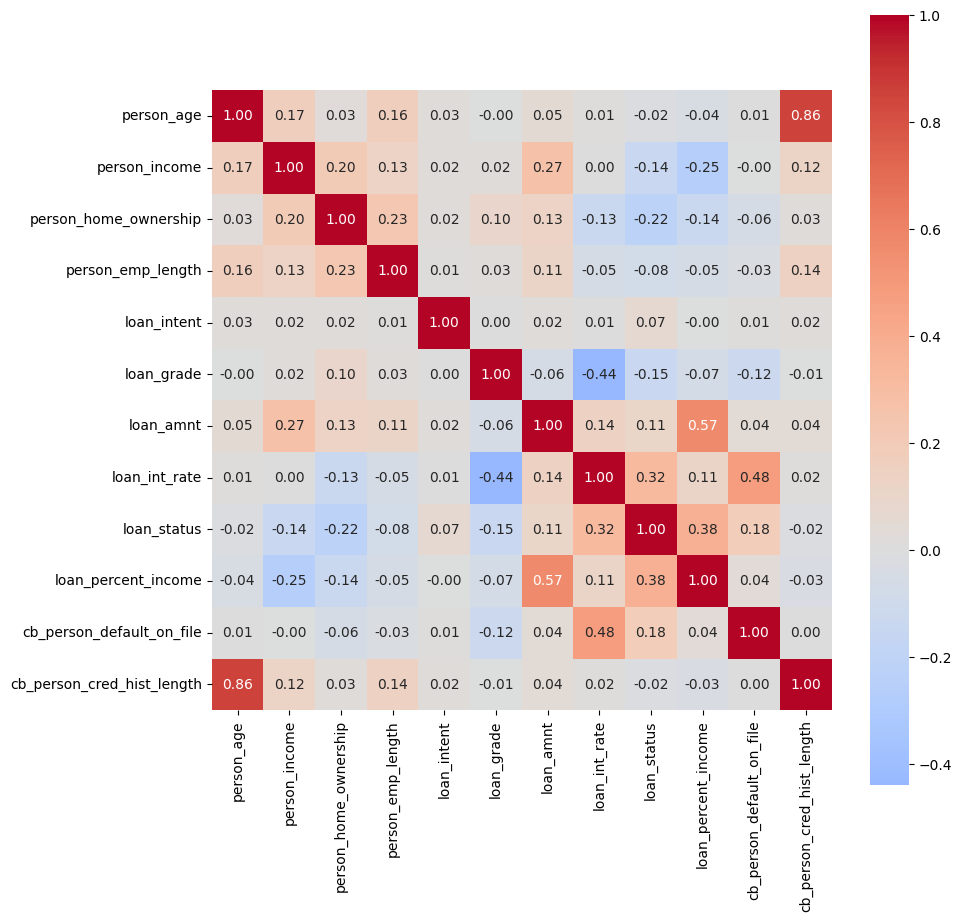

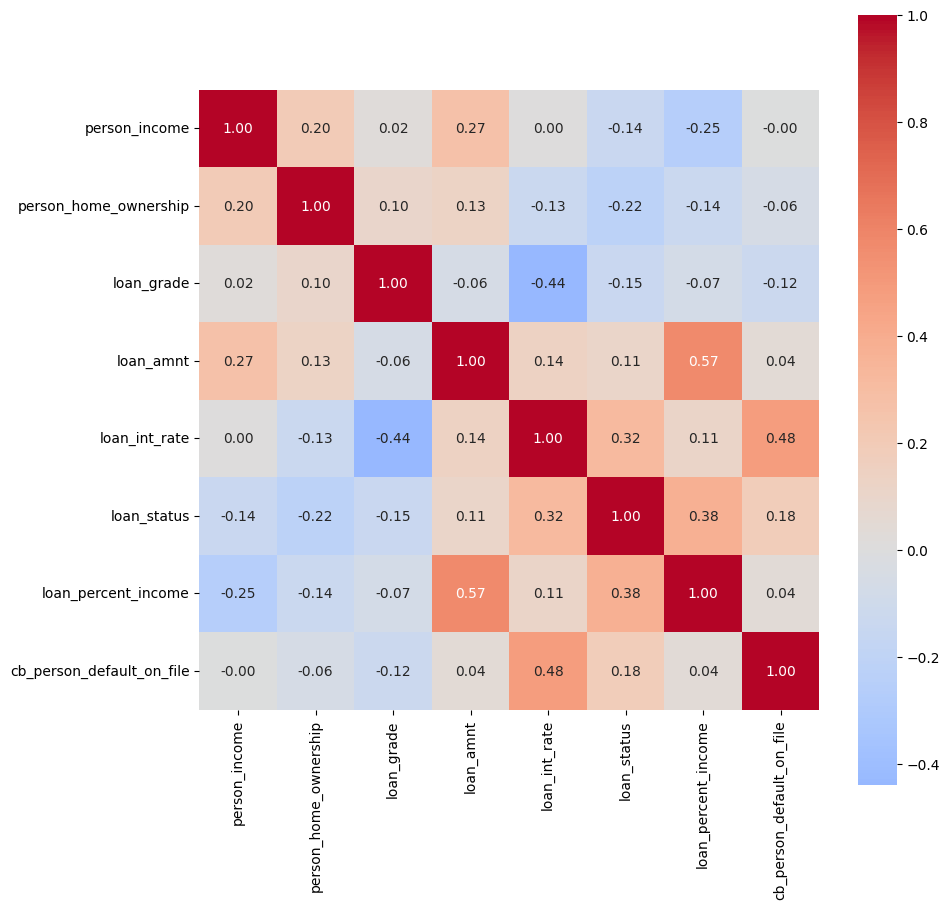

In [45]:
#Строю тепловую карту кореляции(потому что могу)
plt.figure(figsize=(10,10))
sns.heatmap(credit_df_clean.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
#На основе карты удаляю ненужные столбцы
credit_df_clean = credit_df_clean.drop(['person_age', 'person_emp_length', 'loan_intent', 'cb_person_cred_hist_length'], axis=1)
credit_df_clean
#Снова строю карту
plt.figure(figsize=(10,10))
sns.heatmap(credit_df_clean.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)

In [46]:
credit_df_clean

,person_income,person_home_ownership,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file
0,59000,1,1,35000,16.02,1,0.59,1
1,9600,2,2,1000,11.14,0,0.10,0
2,9600,3,3,5500,12.87,1,0.57,0
3,65500,1,3,35000,15.23,1,0.53,0
4,54400,1,3,35000,14.27,1,0.55,1
...,...,...,...,...,...,...,...,...
32576,53000,3,3,5800,13.16,0,0.11,0
32577,120000,3,4,17625,7.49,0,0.15,0
32578,76000,1,2,35000,10.99,1,0.46,0
32579,150000,3,2,15000,11.48,0,0.10,0


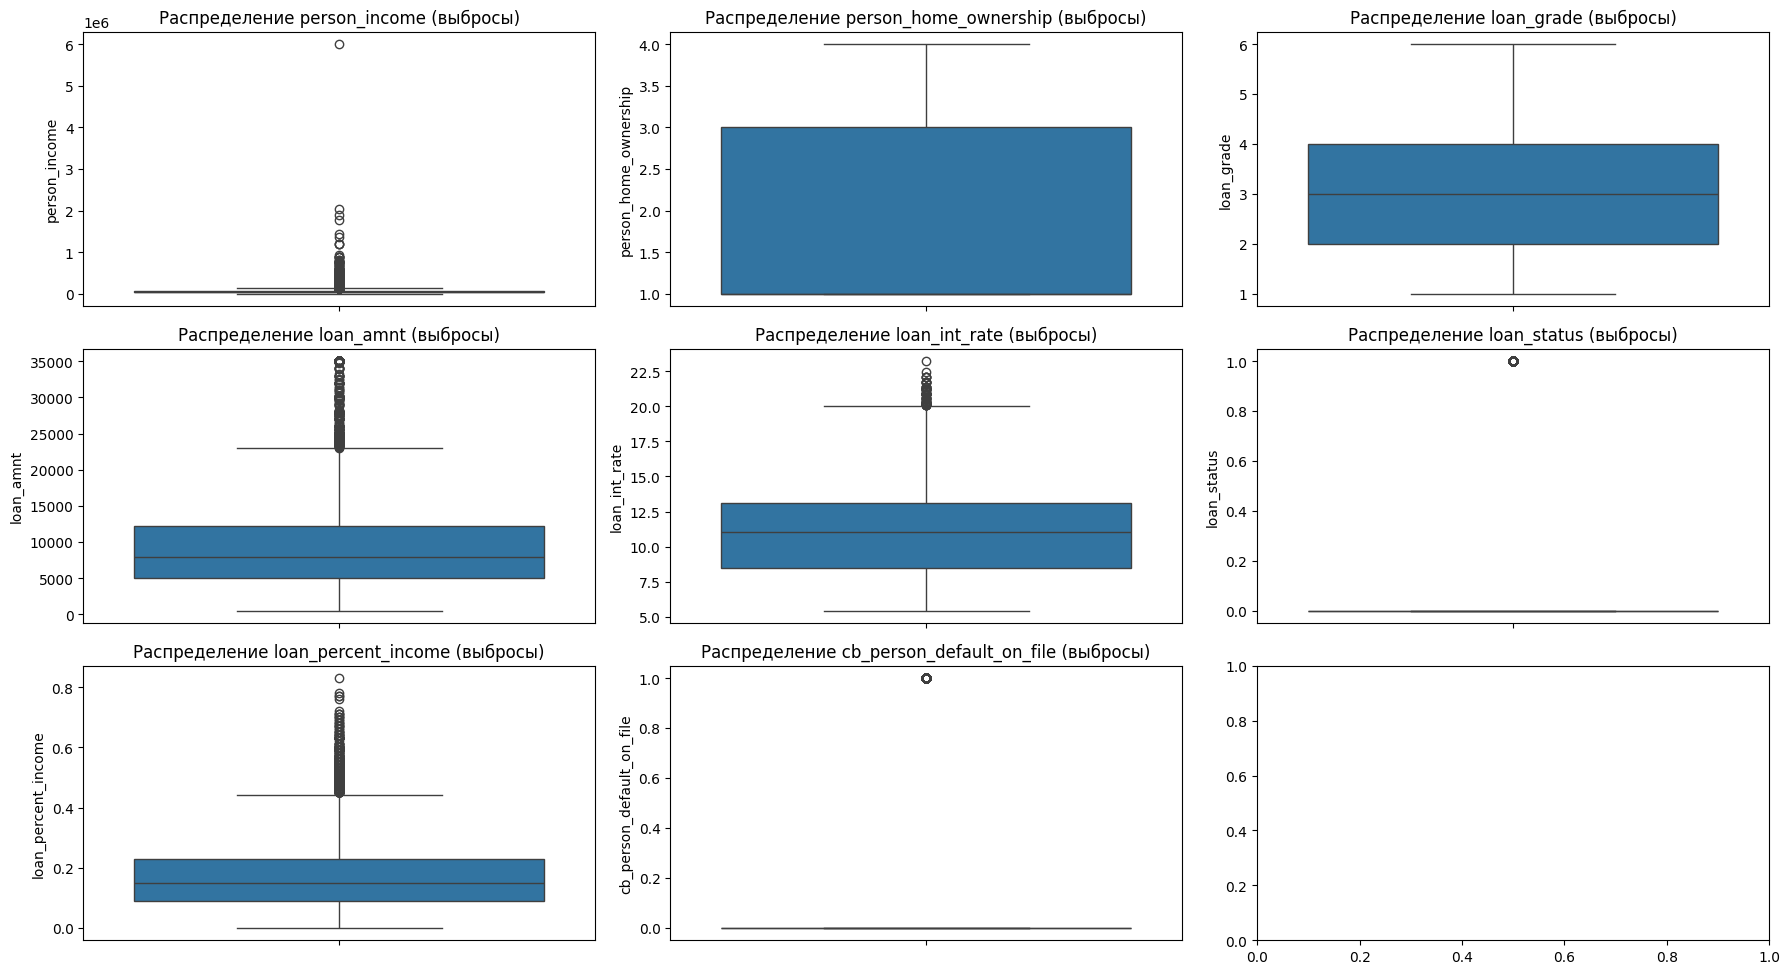

In [47]:
#Смотрю выбросы
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()
colums = credit_df_clean.columns.tolist()

for i, col in enumerate(colums):
    sns.boxplot(data=credit_df_clean, y=col, ax=axes[i])
    axes[i].set_title(f'Распределение {col} (выбросы)')

plt.tight_layout()
plt.show()

In [48]:
#Удаляю выбросы
def remove_outliers_iqr(df, column, multiplier=1.5, verbose=True):
    """Удаляет строки, где column выходит за пределы [Q1 - 1.5*IQR, Q3 + 1.5*IQR]"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    initial_len = len(df)
    df_filtered = df[(df[column] >= lower) & (df[column] <= upper)]
    removed = initial_len - len(df_filtered)
    if verbose:
        print(f"  {column}: удалено {removed} строк ({removed/initial_len*100:.1f}%)")
    return df_filtered

for col in credit_df_clean:
  if col == 'loan_status':
    next
  else:
    credit_df_clean = remove_outliers_iqr(credit_df_clean, col)

  person_income: удалено 1484 строк (4.6%)
  person_home_ownership: удалено 0 строк (0.0%)
  loan_grade: удалено 0 строк (0.0%)
  loan_amnt: удалено 1361 строк (4.4%)
  loan_int_rate: удалено 33 строк (0.1%)
  loan_percent_income: удалено 759 строк (2.6%)
  cb_person_default_on_file: удалено 4982 строк (17.2%)


In [49]:
#Создаю новые признаки
credit_df_clean

,person_income,person_home_ownership,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file
1,9600,2,2,1000,11.14,0,0.10,0
5,9900,2,4,2500,7.14,1,0.25,0
9,10000,2,1,1600,14.74,1,0.16,0
19,10800,3,2,1750,10.99,1,0.16,0
23,10980,2,4,1500,7.29,0,0.14,0
...,...,...,...,...,...,...,...,...
32573,90000,3,4,7200,6.17,0,0.08,0
32575,64500,1,2,5000,11.26,0,0.08,0
32576,53000,3,3,5800,13.16,0,0.11,0
32577,120000,3,4,17625,7.49,0,0.15,0


In [50]:
#Разбираюсь с данными
colums.remove('loan_status')
X_data = credit_df_clean[colums]
y_target = credit_df_clean['loan_status']

<class 'numpy.ndarray'>


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_target, test_size=0.2, random_state=random.randint(1, 10000)
)

In [56]:
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Точность модели: {accuracy*100:.2f}%")

✅ Точность модели: 91.86%
<class 'numpy.ndarray'> <class 'pandas.core.series.Series'>
